# Impact of $A$ on dipole + $m_5$ map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when the $m_5$ is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from lumMag_sampling import *
from mappers import CountMapper, DepthMapper
from spectra import Spectrum

In [2]:
#sources:
NSource_px_th = int(1e6)
#print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Theorical number of sources in one pixel : 1000000


## Data without dipole

In [3]:
DIR_NoDip = "Fit_m5/m5_NoDipole/m5_NoDipole_"
suffix_poiss = "_poissVar"
suffix = "Footprint_study"
fileNoDip = DIR_NoDip + suffix + suffix_poiss +".fits"

data = fitsio.FITS(fileNoDip)
data


  file: Fit_m5/m5_NoDipole/m5_NoDipole_Footprint_study_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS_BAND_z
  2      BINARY_TBL      BAND_z
  3      BINARY_TBL      MAPS_BAND_i
  4      BINARY_TBL      BAND_i
  5      BINARY_TBL      MAPS_BAND_u
  6      BINARY_TBL      BAND_u

In [4]:
band = "u"
HDU_target=f'BAND_{band}'

dfMinuit_NoDip = Table(data[HDU_target].read()).to_pandas()
m5Stats = dfMinuit_NoDip.describe()
m5Stats['A']

/home/victoria/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/victoria/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


count    1.000000e+02
mean     9.558029e-04
std      5.301063e-04
min      5.644600e-15
25%      6.402937e-04
50%      9.341300e-04
75%      1.239147e-03
max      2.937121e-03
Name: A, dtype: float64

## Study without clustering

In [5]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
sufix = "Param_study_NoCluster_poissVar"
suffixNobs = "_Nobs"
outputfile = DIR + sufix + suffixNobs + ".fits"

data2 = fitsio.FITS(outputfile)
data2


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_NoCluster_poissVar_Nobs.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS_u
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_MAPS_i
  4      BINARY_TBL      A_STUDY_MAPS_z

In [6]:
dfMinuit_data2 = Table(data2['A_STUDY'].read())
dfMinuit_data2['A+Am5'] = dfMinuit_data2['A'] + m5Stats['A']['mean']
dfMinuit_data2['A+Am5_err'] = np.sqrt(dfMinuit_data2['A_err']**2 + m5Stats['A']['std']**2)

mask = dfMinuit_data2['valid'] & (dfMinuit_data2["BAND"] == band)
dfMinuit_filtered = dfMinuit_data2[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true,A+Am5,A+Am5_err
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64,float64,float64
01KTHQG59HACPS35J1X2TN127V,999392.0974239863,1000000.0,257.1856371726026,False,0.0,inf,0.0007563092353453001,1.0,0.0002918942760074775,False,0.0,1.0,175.16671917265623,100.0,22.177950676953486,False,0.0,360.0,26.470445441210675,0.0,33.9994063147732,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7,0.0017121121284219927,0.0006051569905007557
01KTHQGD98V8GCH8VXQH6XCDW6,999139.8080150083,1000000.0,257.4138702923665,False,0.0,inf,0.0016618388936477028,1.0,0.0002614837197314799,False,0.0,1.0,171.59120954057687,100.0,9.326536167079084,False,0.0,360.0,13.451341968830075,0.0,16.449646649731918,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7,0.0026176417867243952,0.0005910892068635777
01KTHQGNHQH97EJ9PH2TXEPDNQ,998709.6952827296,1000000.0,257.5635558263748,False,0.0,inf,0.0017512130837242352,1.0,0.0004047712910423102,False,0.0,1.0,158.1410735857428,100.0,12.063732341359426,False,0.0,360.0,-44.232186456368794,0.0,11.993223877713907,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7,0.0027070159768009276,0.0006669726477435643
01KTHQGXVCJFRKJ3PYGGVCERRW,999422.3436597546,1000000.0,257.65952965576435,False,0.0,inf,0.0017399736369152611,1.0,0.00025693978756403046,False,0.0,1.0,150.07034867425205,100.0,8.730555539117105,False,0.0,360.0,4.087802626794416,0.0,15.789852248641262,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7,0.0026957765299919535,0.00058909317532921
01KTHQH33W7PMV4BG759652GFZ,999116.5251937228,1000000.0,256.933750999975,False,0.0,inf,0.0016105145016101436,1.0,0.00031943562376402347,False,0.0,1.0,172.08042633712233,100.0,10.040524295250819,False,0.0,360.0,-21.254769917027843,0.0,15.664108926841255,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7,0.0025663173946868364,0.0006189118131975774
01KTHQHDHKGZX4F9ZJCYKK6024,999172.3757712409,1000000.0,258.30870213912567,False,0.0,inf,0.0012622357426304983,1.0,0.00025691233073414936,False,0.0,1.0,161.12360009331405,100.0,12.014461161496627,False,0.0,360.0,3.8852616481088433,0.0,21.758651515208953,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0015998587196060573,168,-7,0.002218038635707191,0.0005890812002341063
01KTHQHKXRQA9Q21S24VBMYKHJ,998897.7891196167,1000000.0,257.69972211134154,False,0.0,inf,0.002040454685419284,1.0,0.000346129186363453,False,0.0,1.0,160.0198388943298,100.0,8.45691177387711,False,0.0,360.0,-28.721066402524066,0.0,11.863265175297656,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0017575106248547913,168,-7,0.0029962575784959764,0.0006331019889706778
01KTHQHVY6FTV2WX6AZ70498J1,999303.4913681812,1000000.0,257.5467682702001,False,0.0,inf,0.0021075629313328376,1.0,0.0002598825856534302,False,0.0,1.0,158.99372932934247,100.0,7.329646418691496,False,0.0,360.0,11.651008503020199,0.0,13.014132523259068,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0019306977288832496,168,-7,0.0030633658244095304,0.000590382649738214
01KTHQJ1XKJJ11XDCTW0GWAR3B,999446.0534069708,1000000.0,257.81289407692384,False,0.0,inf,0.0022090920613927244,1.0,0.0002607532998783672,False,0.0,1.0,155.22088832645915,100.0,6.85467667977322,False,0.0,360.0,-0.89731

Saving m5_A_study_diffARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_diffARaDec_NoCluster_band_u_PoissVar.pdf


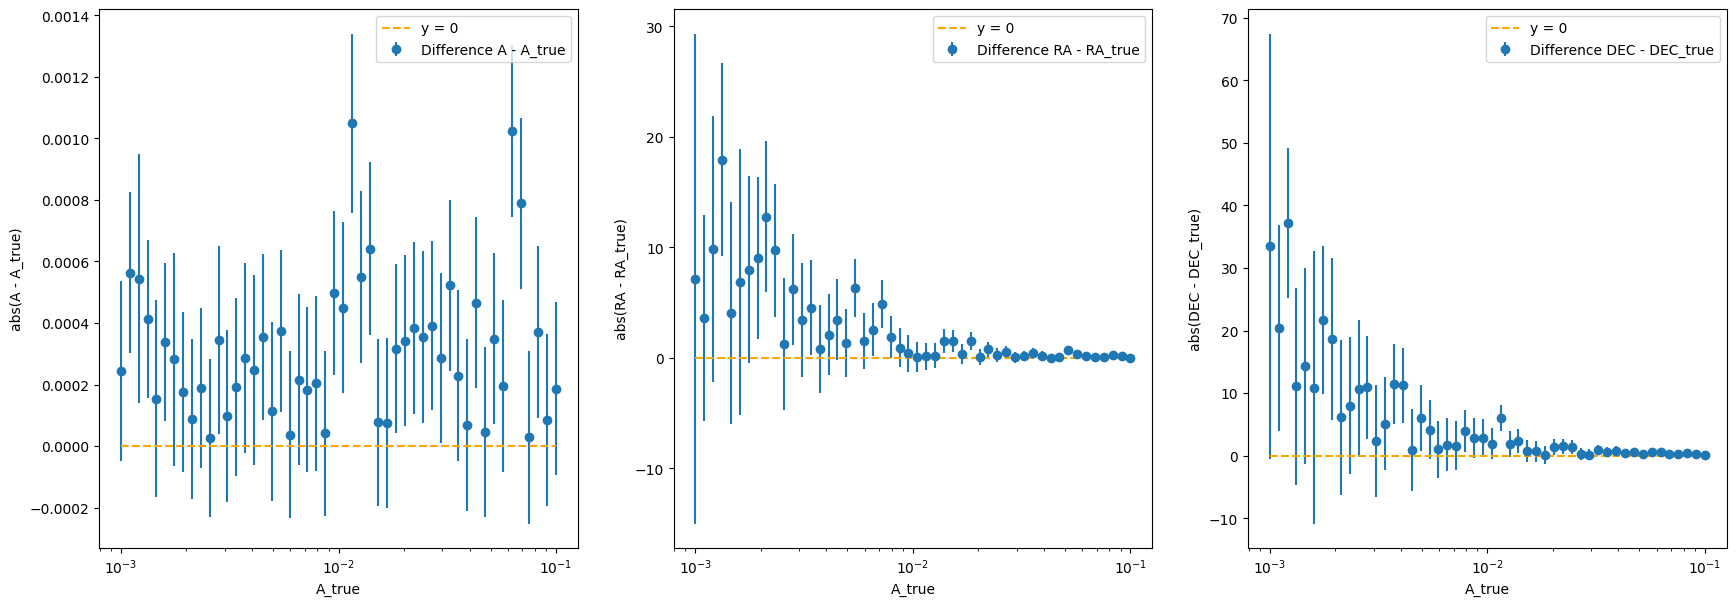

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)

clSuffix_NoClust = f"NoCluster_band_{band}"
poissSuffix = "_PoissVar"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_NoClust = f"{output_path}Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_{clSuffix_NoClust}/"

suffix = f"m5_A_study_diffARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_ratioARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_ratioARaDec_NoCluster_band_u_PoissVar.pdf


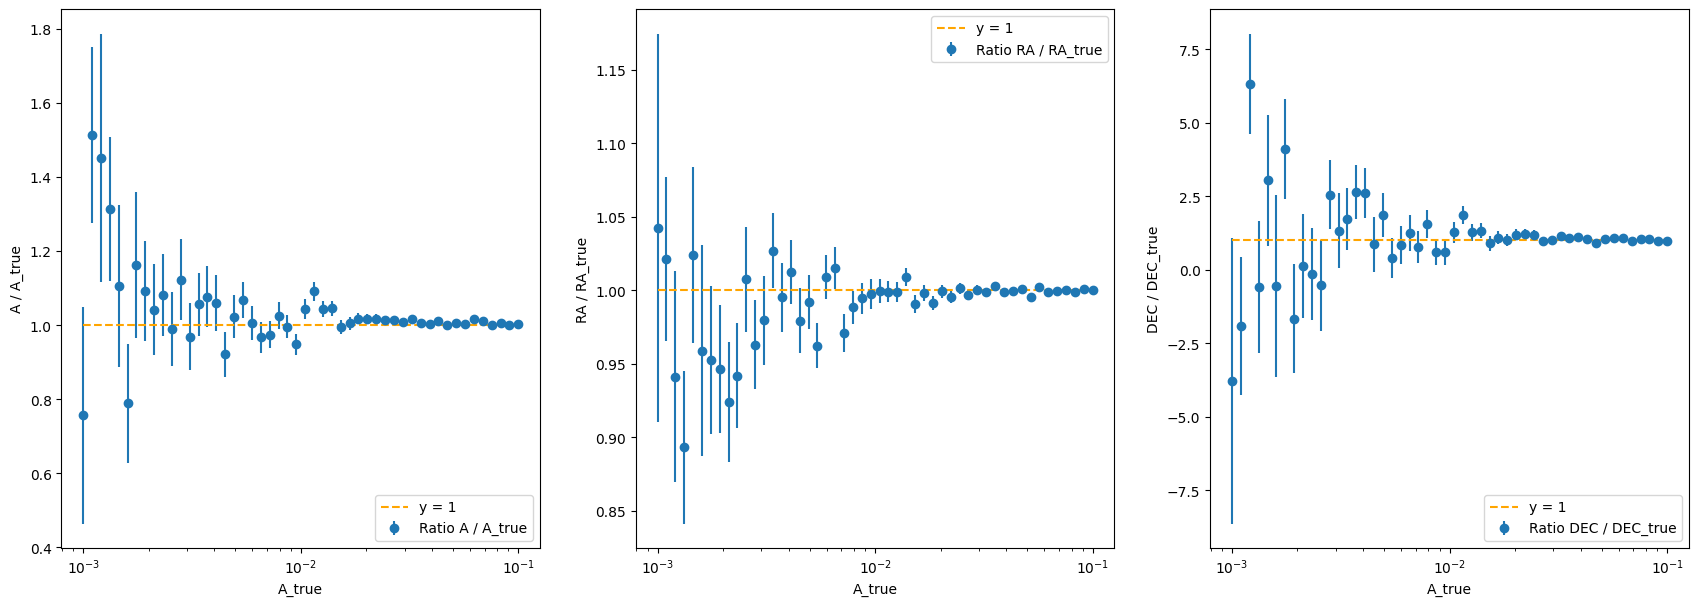

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")

suffix = f"m5_A_study_ratioARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_ARaDec_NoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_ARaDec_NoCluster_band_u_PoissVar.pdf


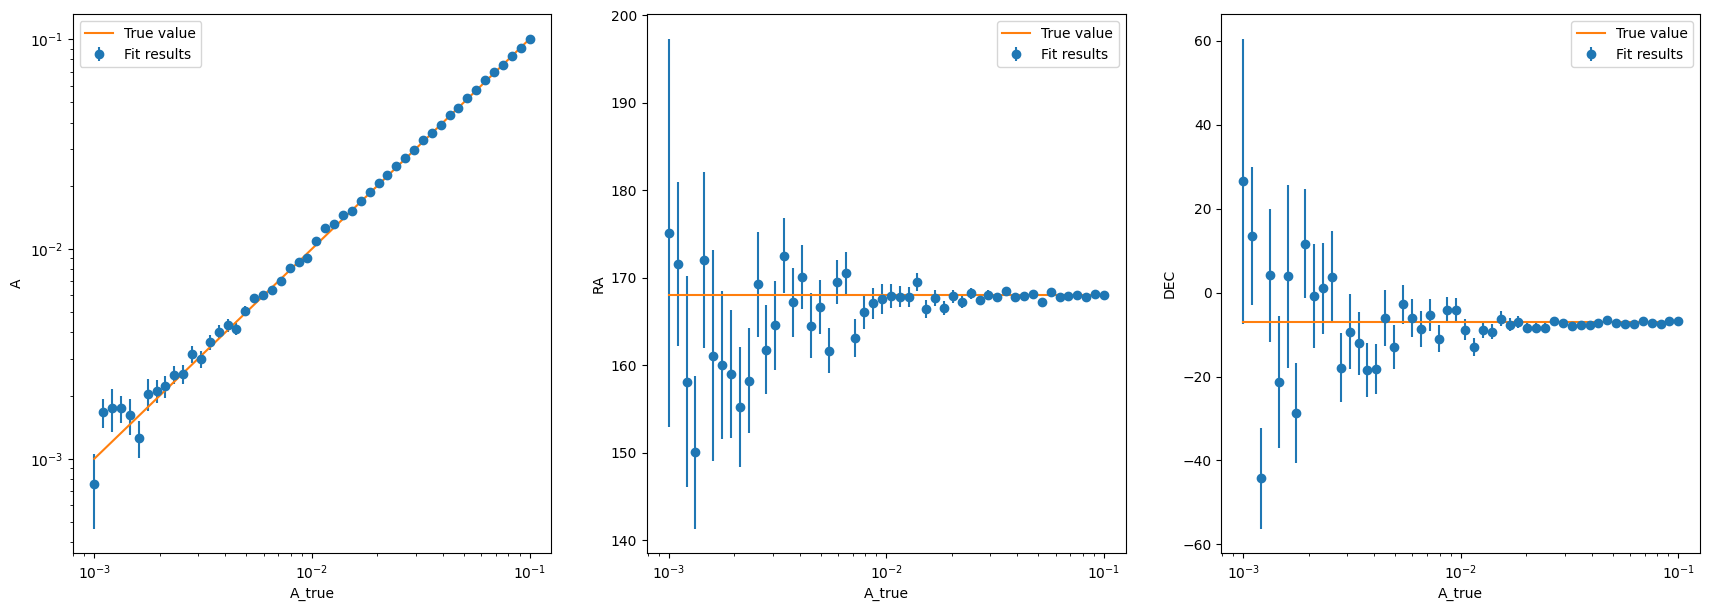

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False, yscale='log')
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
# ax[0].legend(loc="lower right")
# ax[2].legend(loc="lower right")

suffix = f"m5_A_study_ARaDec_{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_A_valNoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_A_valNoCluster_band_u_PoissVar.pdf


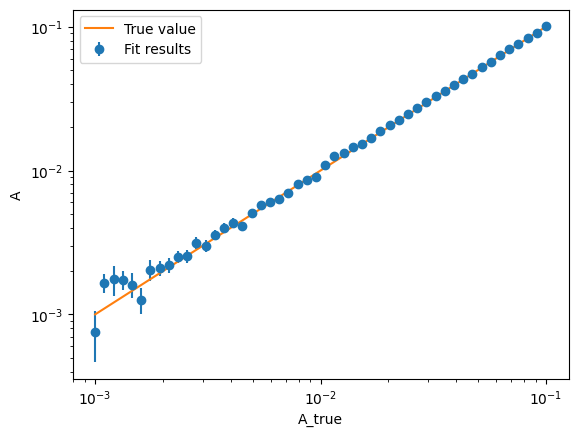

In [10]:
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=2, surface=False, yscale='log')

suffix = f"m5_A_study_A_val{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

Saving m5_A_study_A_DiffRatioNoCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_NoCluster/Simul_Magnitude_ParamStudy_NoCluster_band_u/m5_A_study_A_DiffRatioNoCluster_band_u_PoissVar.pdf


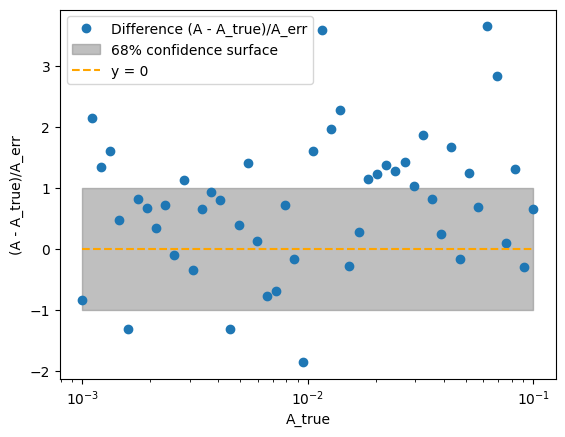

In [11]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A", nsigma=1, surface=False)

suffix = f"m5_A_study_A_DiffRatio{clSuffix_NoClust}"
get_savefig(plt, output_path_NoClust, suffix + poissSuffix)

## Study with clustering

count    10000.000000
mean         0.000704
std          0.000298
min          0.000033
25%          0.000485
50%          0.000681
75%          0.000896
max          0.002026
Name: A, dtype: float64

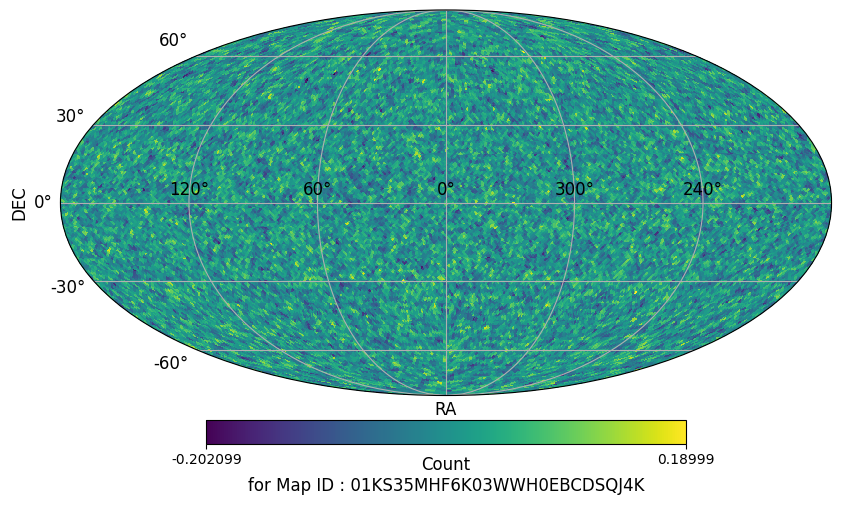

In [12]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

with fitsio.FITS(clFile, 'rw') as fits:
    dfNumpy = Table(fits['FIT_NUMPY'].read()).to_pandas()
    clMapper = CountMapper.from_map_fits(fits, idx=0, nest=False) #first clustering map
    clMapper = clMapper.invert_nest()
clMapper.plot()

clStats = dfNumpy.describe()
clStats['A']

In [13]:
DIR = "Fit_m5/m5_Dipole/m5_Dipole_"
suffix = "Param_study_Cluster_poissVar"
outputfile = DIR + suffix + suffixNobs + ".fits"

data3 = fitsio.FITS(outputfile)
data3


  file: Fit_m5/m5_Dipole/m5_Dipole_Param_study_Cluster_poissVar_Nobs.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS_z
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_MAPS_i
  4      BINARY_TBL      A_STUDY_MAPS_u

In [14]:
dfMinuit_data3 = Table(data3['A_STUDY'].read())
dfMinuit_data3['A+Am5'] = dfMinuit_data3['A'] + m5Stats['A']['mean']
dfMinuit_data3['A+Am5_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + m5Stats['A']['std']**2)
dfMinuit_data3['A-Am5'] = dfMinuit_data3['A'] - m5Stats['A']['mean']
dfMinuit_data3['A-Am5_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + m5Stats['A']['std']**2)
dfMinuit_data3['A-Acl'] = dfMinuit_data3['A'] - clStats['A']['mean']
dfMinuit_data3['A-Acl_err'] = np.sqrt(dfMinuit_data3['A_err']**2 + clStats['A']['std']**2)
dfMinuit_data3['A+Am5-Acl'] = dfMinuit_data3['A+Am5'] - clStats['A']['mean']
dfMinuit_data3['A+Am5-Acl_err'] = np.sqrt(dfMinuit_data3['A+Am5_err']**2 + clStats['A']['std']**2)
dfMinuit_data3['A-Am5-Acl'] = dfMinuit_data3['A-Am5'] - clStats['A']['mean']
dfMinuit_data3['A-Am5-Acl_err'] = np.sqrt(dfMinuit_data3['A-Am5_err']**2 + clStats['A']['std']**2)

mask = dfMinuit_data3['valid'] & (dfMinuit_data3["BAND"] == band)
dfMinuit_filtered = dfMinuit_data3[mask].copy()
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,Nth_ID,Ratio_ID,BAND,N*_true,A_true,ra_true,dec_true,Cluster_ID,A+Am5,A+Am5_err,A-Am5,A-Am5_err,A-Acl,A-Acl_err,A+Am5-Acl,A+Am5-Acl_err,A-Am5-Acl,A-Am5-Acl_err
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str26,str26,str1,int64,float64,int64,int64,str26,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
01KTHSX1S8XGGYGGEFS74G71NQ,997533.7390302195,1000000.0,257.620915450796,False,0.0,inf,0.0023998725328758814,1.0,0.00034562632877405586,False,0.0,1.0,191.12349688198333,100.0,8.291256645670714,False,0.0,360.0,41.15493870424058,0.0,10.135966630232016,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0033556754259525742,0.0006328272070066473,0.0014440696397991888,0.0006328272070066473,0.0016955298203146269,0.0004560590551071403,0.0026513327133913197,0.000699287191739717,0.0007397269272379343,0.000699287191739717
01KTHSX85YMT5MXZ272EZEM0T1,997391.7399678271,1000000.0,257.12762141402345,False,0.0,inf,0.0019304344712937711,1.0,0.0003702534929706198,False,0.0,1.0,190.41624929854652,100.0,11.488838509033755,False,0.0,360.0,47.520464090941125,0.0,11.919829962056657,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0028862373643704638,0.000646606807761059,0.0009746315782170785,0.000646606807761059,0.0012260917587325168,0.0004749946859285172,0.0021818946518092092,0.0007117813333084347,0.0002702888656558241,0.0007117813333084347
01KTHSXDSRE0ZTW2B8PQ84PMTF,997338.0739908501,1000000.0,257.42745286697755,False,0.0,inf,0.0022455007969655414,1.0,0.00029151962119882313,False,0.0,1.0,184.99934647894318,100.0,7.461006269647129,False,0.0,360.0,26.3298429893542,0.0,11.800086922367662,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0032013036900422343,0.0006049763667532043,0.0012896979038888488,0.0006049763667532043,0.0015411580844042869,0.00041655250827151574,0.0024969609774809797,0.0006741874419872366,0.0005853551913275944,0.0006741874419872366
01KTHSXKFBZA1PGBSP5J76TWRS,996917.7328326294,1000000.0,257.1077535469085,False,0.0,inf,0.0025651925649343033,1.0,0.000264255474072941,False,0.0,1.0,183.9158193124778,100.0,6.070715094081081,False,0.0,360.0,15.190214717969072,0.0,10.68625807077431,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.003520995458010996,0.0005923205807360716,0.0016093896718576107,0.0005923205807360716,0.0018608498523730488,0.0003979488135186492,0.0028166527454497416,0.0006628544131005714,0.0009050469592963563,0.0006628544131005714
01KTHSXR44CJ1H794KH4YV3X0Y,997332.3649505902,1000000.0,257.52759633754613,False,0.0,inf,0.0021082269025544647,1.0,0.0003004775020076496,False,0.0,1.0,197.98022411580627,100.0,8.094370908083334,False,0.0,360.0,28.8472610849005,0.0,12.434085943430532,False,-90.0,90.0,True,01KSAFJYRKG5T71B608D7E8YW0,01KS86Z9ZVNDZJB0VA9VVNCNJB,u,1000000,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K,0.0030640297956311575,0.000609343453233691,0.001152424009477772,0.000609343453233691,0.0014038841899932102,0.00042286999398886526,0.002359687083069903,0.0006781089489176095,0.00044808129691651765,0.0006781089489176095
01KTHSXY7TSP1XNNDASGVWVFH3,997391.4292249543,1000000.0,257.27016243571416,False,0.0,inf,0.0027010267285761244,1.0,0.00029789823885898576,False,0.0,1.0,183.1710503813481,100.0,6.323664390915127,False,0.0,360.0,28.37113636397932,0.0,9.722590472964384,False,-90.0,90.0,True,01KSA

Saving m5_A_study_Acorr_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_Cluster_band_u_PoissVar.pdf


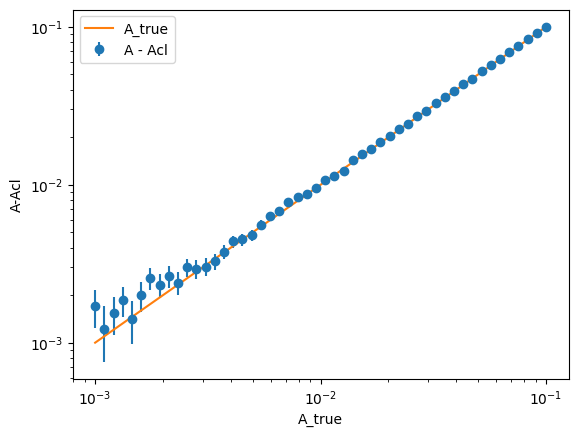

In [15]:
compareFit_val(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl")

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
suffix = f"m5_A_study_Acorr_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_Acorr_DiffRatioCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_DiffRatioCluster_band_u_PoissVar.pdf


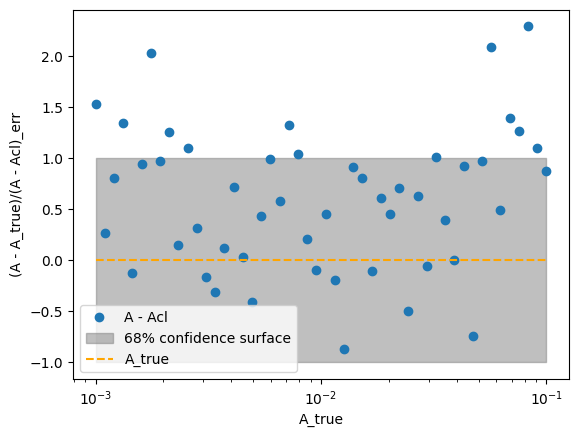

In [16]:
compareFit_diffRatio(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, label_true="A_true", label_fit="A - Acl", ylabel="(A - A_true)/(A - Acl)_err")

suffix = f"m5_A_study_Acorr_DiffRatio{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_Acorr_CompareCluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_Acorr_CompareCluster_band_u_PoissVar.pdf


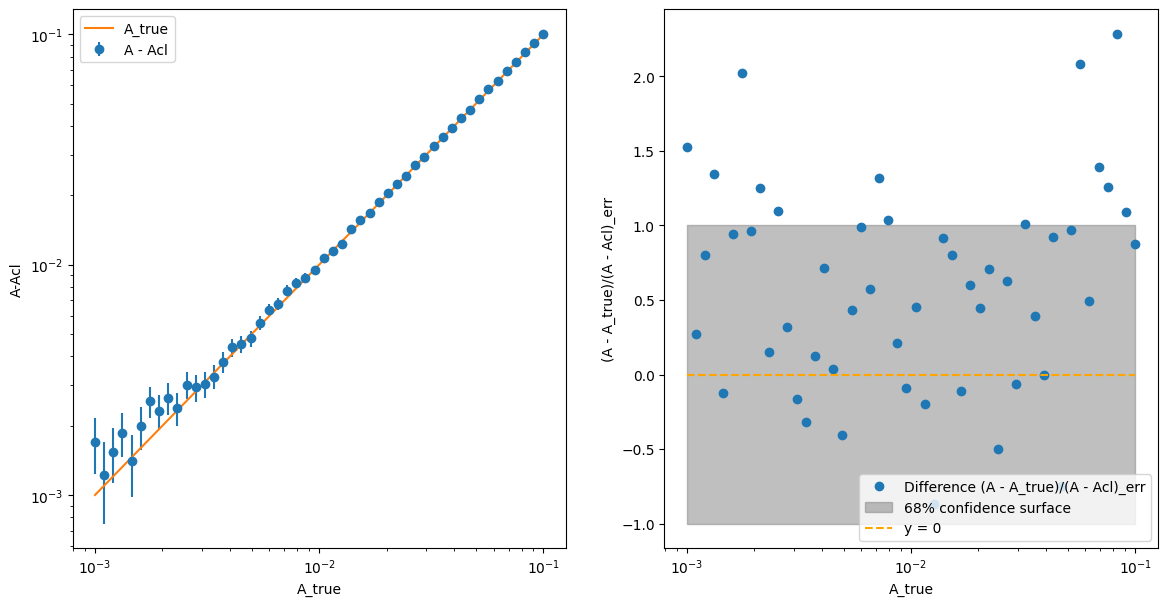

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(2*7,7))
compareFit_val(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, yscale='log', label_true="A_true", label_fit="A - Acl", figax=(fig, ax[0]))
compareFit_diffRatio(dfMinuit_filtered, "A", "A-Acl", ytrue = "A_true", nsigma=1, surface=False, ylabel="(A - A_true)/(A - Acl)_err", figax=(fig, ax[1]))
ax[1].legend(loc='lower right')

suffix = f"m5_A_study_Acorr_Compare{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_diffARaDec_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_diffARaDec_Cluster_band_u_PoissVar.pdf


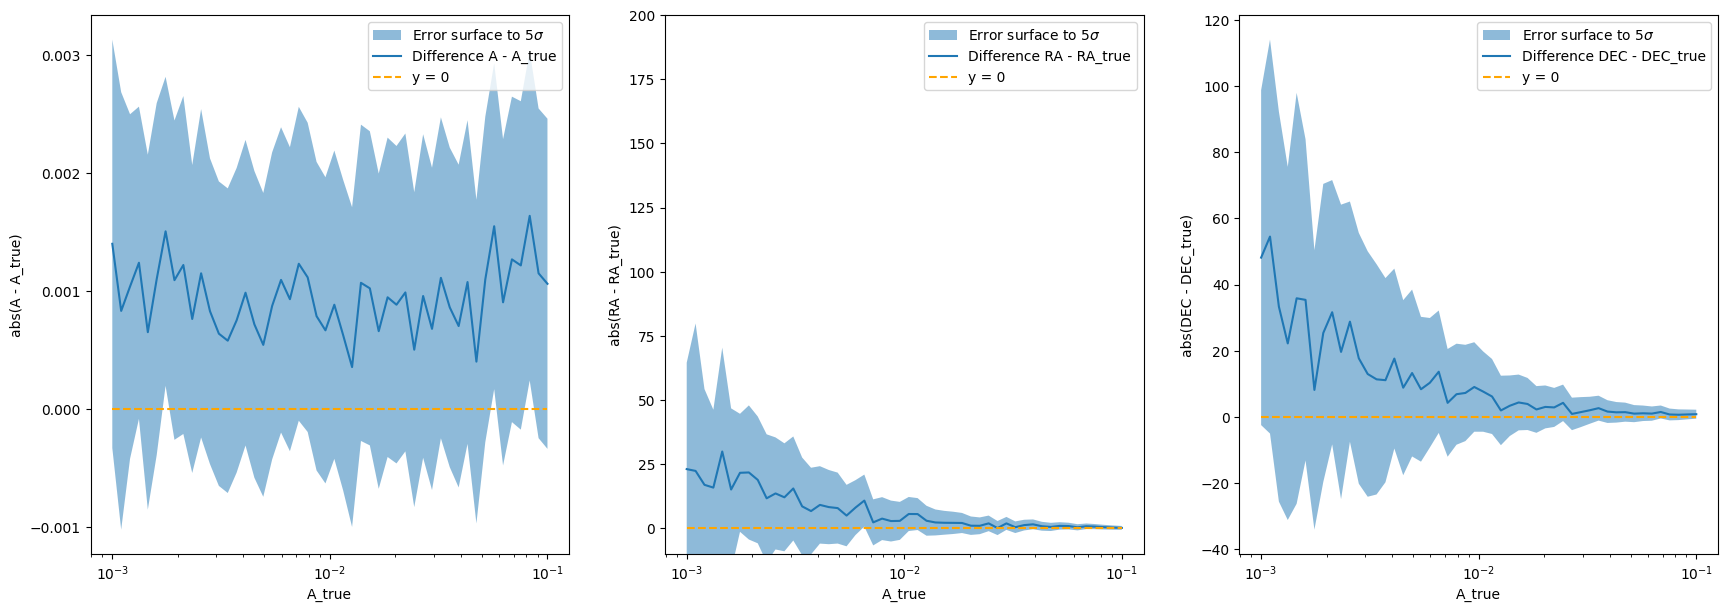

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]))
ax[1].set_ylim([-10, 200])  #used for band u
#ax[1].set_ylim([-10, 130]) #used for band i

clSuffix_Clust = f"Cluster_band_{band}"
output_path = "Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/"
output_path_Clust = f"{output_path}Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_{clSuffix_Clust}/"
suffix = f"m5_A_study_diffARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving m5_A_study_ratioARaDec_Cluster_band_u_PoissVar in Simul_Figures/Simul_Magnitude/Simul_Magnitude_ParamStudy/Simul_Magnitude_ParamStudy_Cluster/Simul_Magnitude_ParamStudy_Cluster_band_u/m5_A_study_ratioARaDec_Cluster_band_u_PoissVar.pdf


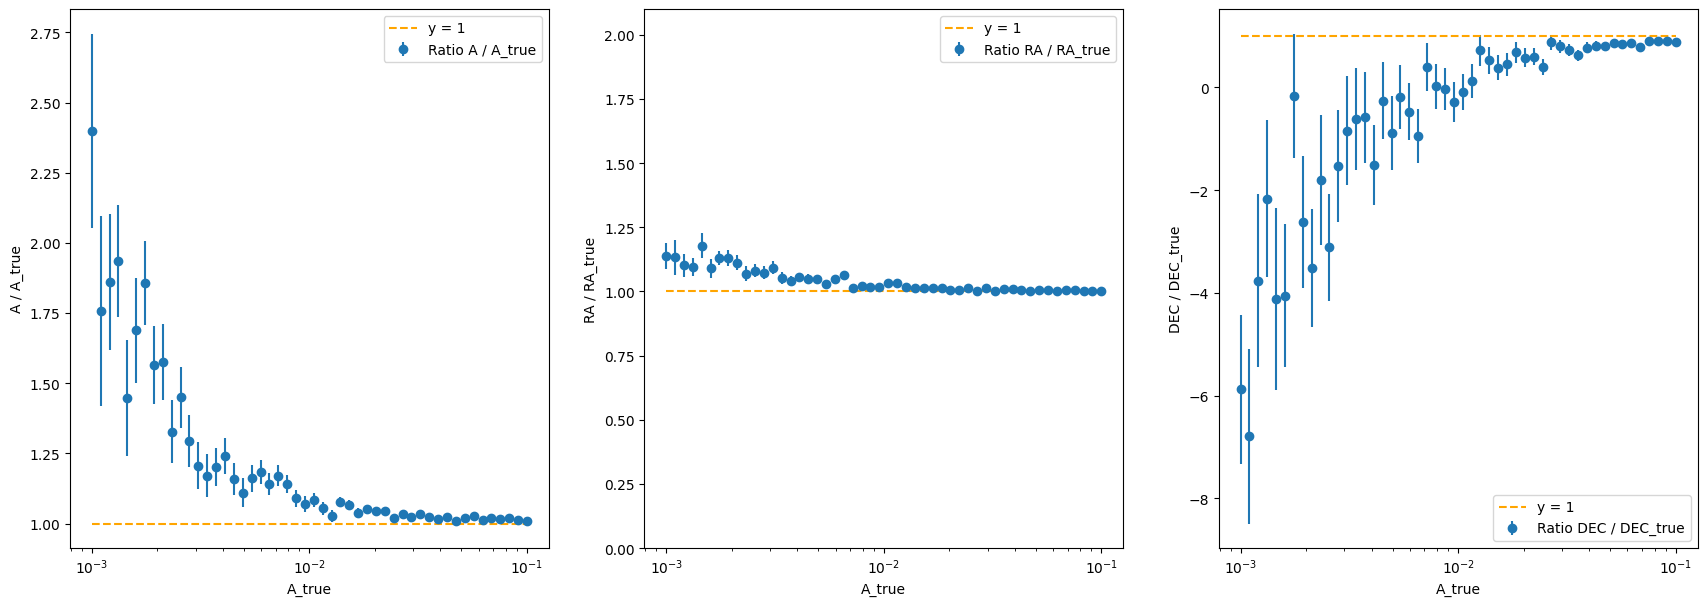

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=2, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=2, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=2, figax=(fig, ax[2]), surface=False)
#ax[0].legend(loc="lower right")
ax[2].legend(loc="lower right")
#ax[1].set_ylim([0.3, 2]) #used for band i
ax[1].set_ylim([0, 2.1]) #used for band u

suffix = f"m5_A_study_ratioARaDec_{clSuffix_Clust}"
get_savefig(plt, output_path_Clust, suffix + poissSuffix)

Saving CorrectMap_m5band_u_DipCluster_PoissVar in Simul_Figures/Simul_Magnitude/CorrectMap_m5band_u_DipCluster_PoissVar.pdf


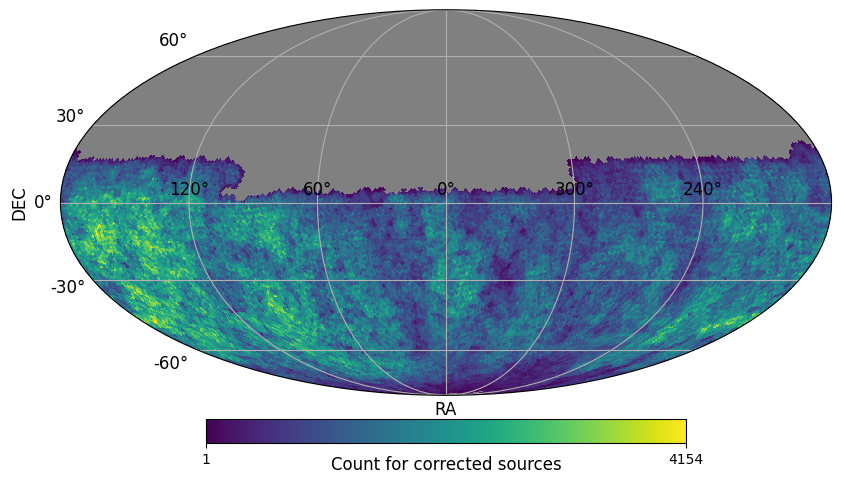

In [20]:
correctMapper = CountMapper.from_map_fits(data3, 49, HDU=f"A_STUDY_MAPS_{band}", IDinunit=False)
correctMapper._set_suffixTextPlot(unit = "corrected sources")
correctMapper.set_mask()
correctMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
suffix = f"CorrectMap_m5band_{band}_DipCluster"
get_savefig(plt, output_path, suffix + poissSuffix)

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.594e+07 (χ²/ndof = 324.3)│              Nfcn = 158              │
│ EDM = 1.36e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 9.0189e2  │ 0.0000e2  │            │            │    0    │         │       │
│ 1 │ A    │1.1937e-16 │0.0000e-16 │            │            │    0    │    1    │       │
│ 2 │ ra   │ 1.0526e2  │ 0.0000e2  │            │            │    0    │   360   │       │
│ 3 │ dec  │  8.53e1   │  0.00e1   │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘

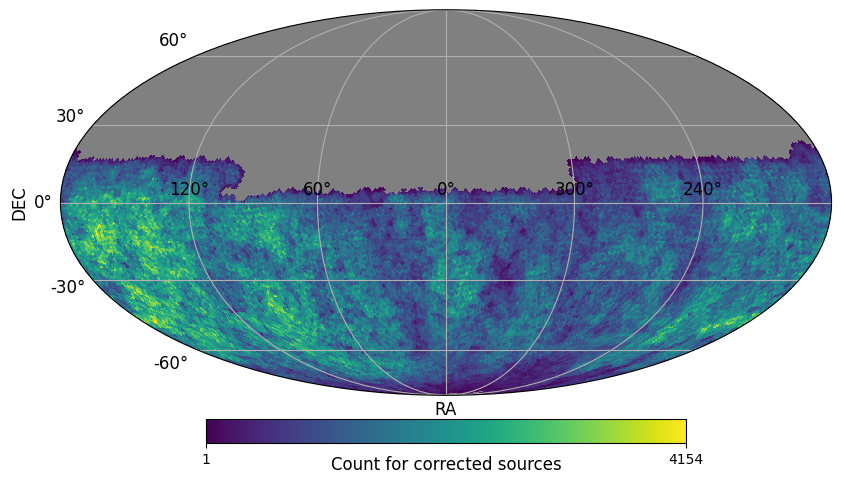

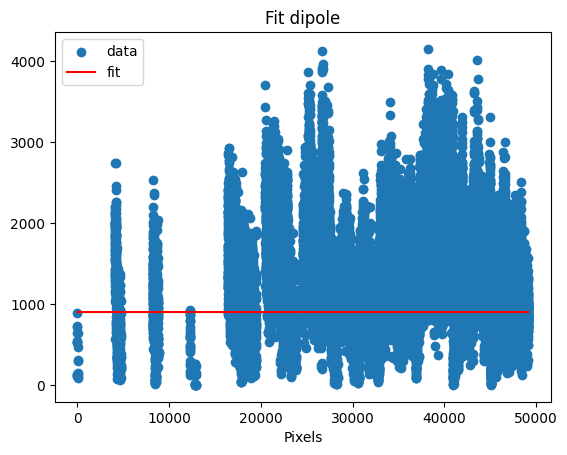

In [21]:
correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.531e+07 (χ²/ndof = 311.6)│              Nfcn = 638              │
│ EDM = 4.24e-08 (Goal: 0.0002)    │            time = 5.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  923.89   │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 1 │ A    │   9e-15   │579819610e-15│   -9e-15   │579819610e-15│    0    │    1    │       │
│ 2 │ ra   │  0.10e3   │  0.18e3   │  -0.10e3   │   0.18e3   │    0    │   360   │       │
│ 3 │ dec  │    86     │    172    │    -172    │     4      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │  -9e-15   │579819610e-15│  -0.10e3  │  0.18e3   │   -172    │     4     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   False   │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   False   │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   True    │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────────────┐
│     │                  N*                   A                  ra                 dec │
├─────┼─────────────────────────────────────────────────────────────────────────────────┤
│  N* │              0.0311       31.491215e-15              -0.044              -0.007 │
│   A │       31.491215e-15            1.98e-20 -27.360924629776e-9  -4.357176859366e-9 │
│  ra │              -0.044 -27.360924629776e-9            1.44e+05                 6e3 │
│ dec │              -0.007  -4.357176859366e-9                 6e3            3.79e+03 │
└─────┴─────────────────────────────────────────────────────────────────────────────────┘

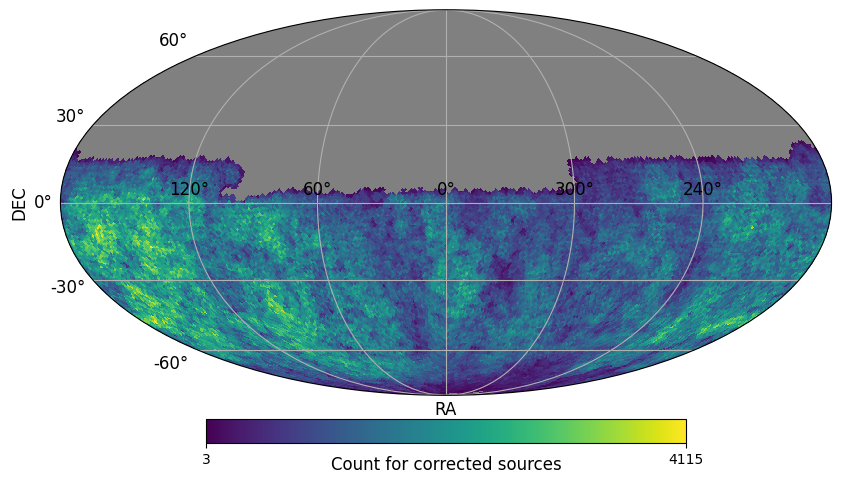

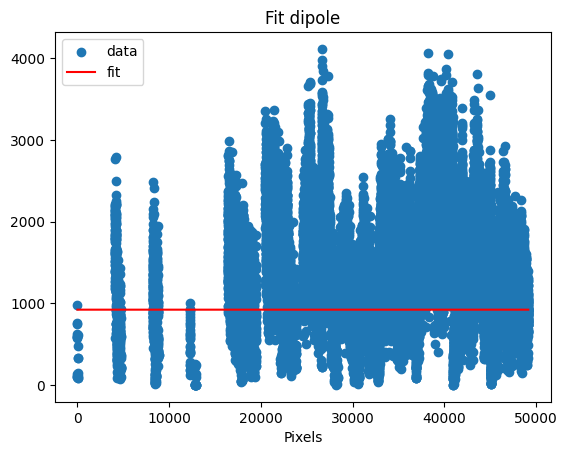

In [22]:
correctMapper = CountMapper.from_map_fits(data2, 49, HDU=f"A_STUDY_MAPS_{band}", IDinunit=False)
correctMapper._set_suffixTextPlot(unit = "corrected sources")
correctMapper.set_mask()
correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))

## Fitting Nobs

### Getting ratio

SED band u ratio : 0.013291492416839587


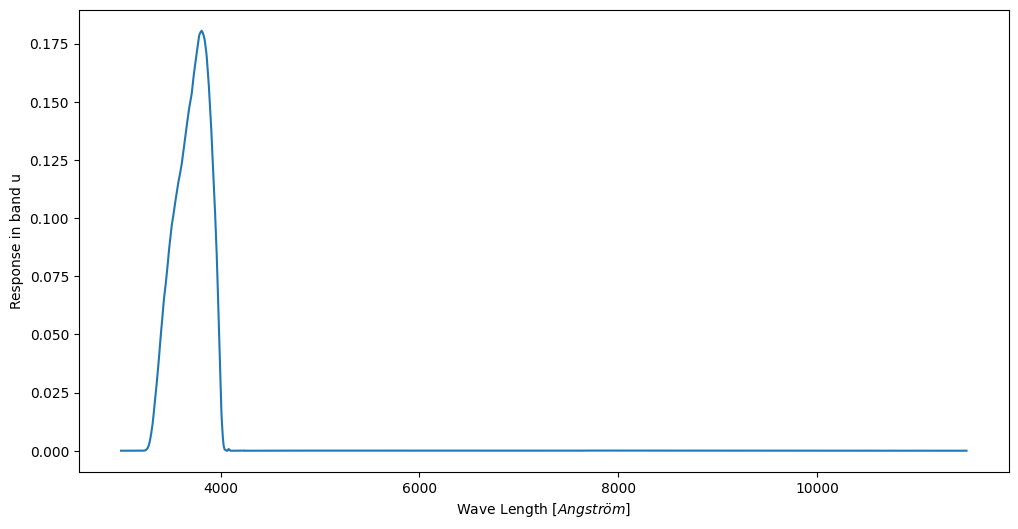

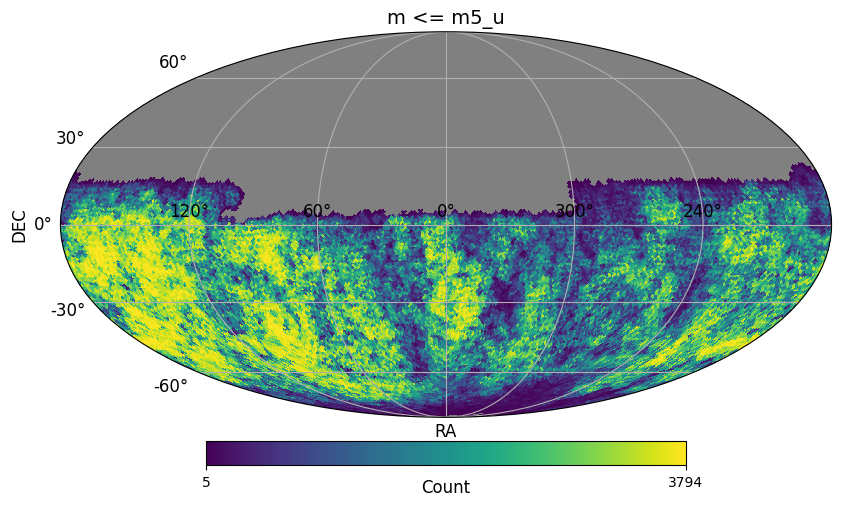

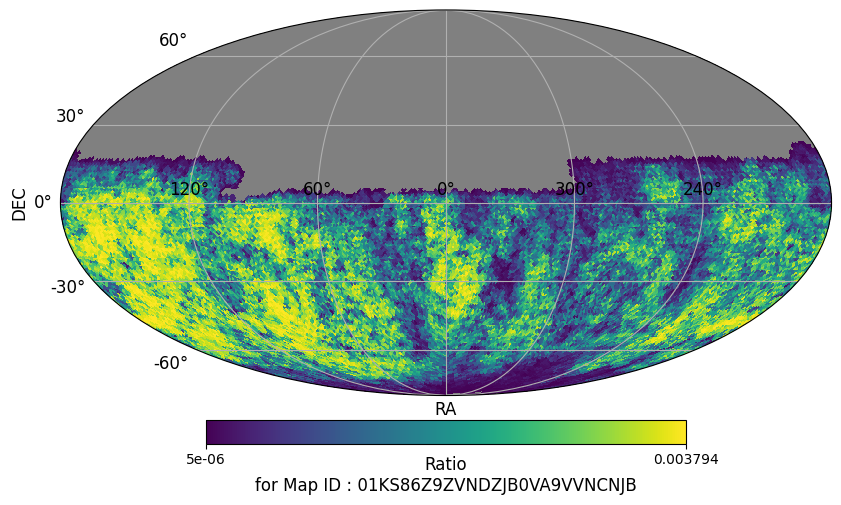

In [26]:
DIR_m5 = '../data/'
FILE = DIR_m5 + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
dm.select_band(band)
dm.set_mask()

DIR_SED = "../data/data SED/SED GAL/COSMOS/"
FILE_SED = "Ell1_A_0"
file = DIR_SED + FILE_SED + ".sed"
refSpectum = Spectrum.read_sed(file)

file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="");

_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

DIR_cat = "Catalog_m5/Catalog_m5Ratio/"
sufix = "testRatio"
file_cat = DIR_cat + sufix + '.fits'

dataN, data_ID = read_lumMag_fits(file_cat, 0, L_bandRatio=L_bandRatio, to_band=band)

_, hpmap_band = dm._get_band_map(band)
NSource_px = cut_m52map(dataN[f"m_{band}"], hpmap_band)
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= f"m <= m5_{band}")

ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'Ratio')
ratioMapper.set_mask()
ratioMapper.set_mapID(data_ID)
ratioMapper.plot("Masked", norm="hist")

### Getting Nobs

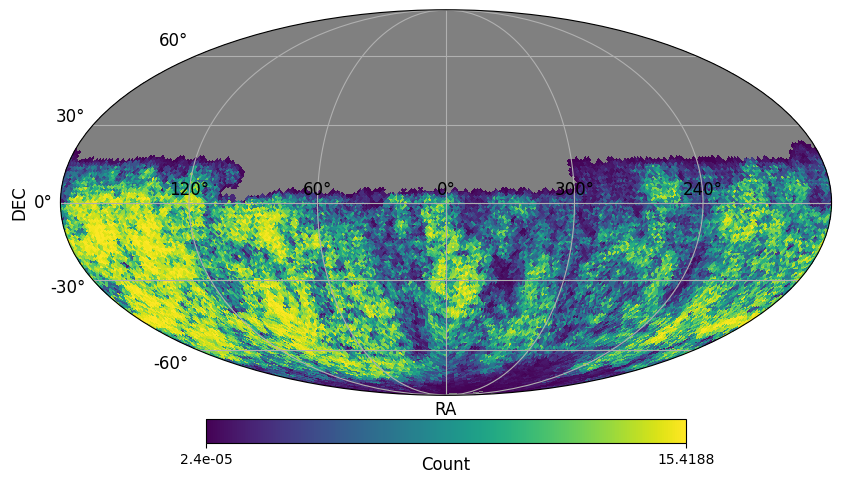

In [24]:
observMapper = CountMapper.from_map(ratioMapper.map * correctMapper.map)
observMapper.set_mask()
observMapper.plot("Masked", norm="hist")

### New model definition

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8840 (χ²/ndof = 0.2)       │              Nfcn = 516              │
│ EDM = 1.3e-07 (Goal: 0.0002)     │            time = 7.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  1.316e3  │  0.009e3  │  -0.009e3  │  0.009e3   │    0    │         │       │
│ 1 │ A    │   0.437   │   0.011   │   -0.011   │   0.011    │    0    │    1    │       │
│ 2 │ ra   │   135.7   │    1.1    │    -1.1    │    1.1     │    0    │   360   │       │
│ 3 │ dec  │   -30.0   │    1.5    │    -1.5    │    1.5     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -9     │     9     │  -0.011   │   0.011   │   -1.1    │    1.1    │   -1.5    │    1.5    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │      78.1 -69.65e-3      -1.4       9.4 │
│   A │ -69.65e-3  0.000123   1.53e-3  -9.45e-3 │
│  ra │      -1.4   1.53e-3      1.29      -0.2 │
│ dec │       9.4  -9.45e-3      -0.2      2.24 │
└─────┴─────────────────────────────────────────┘

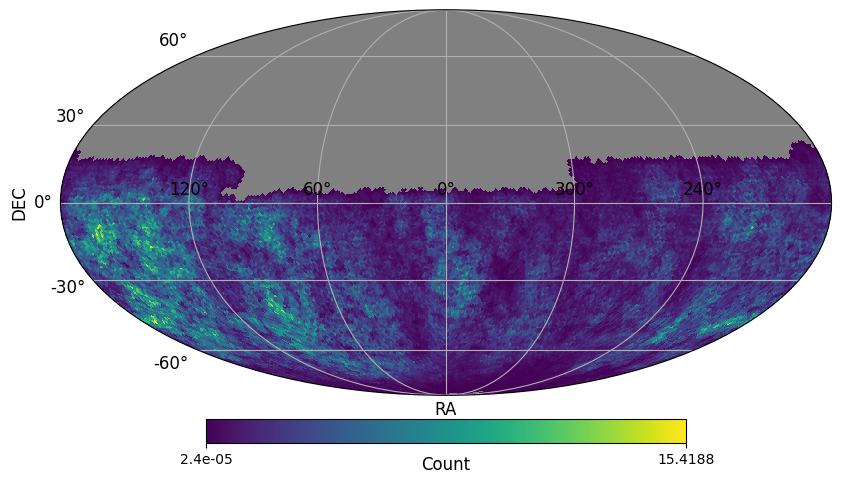

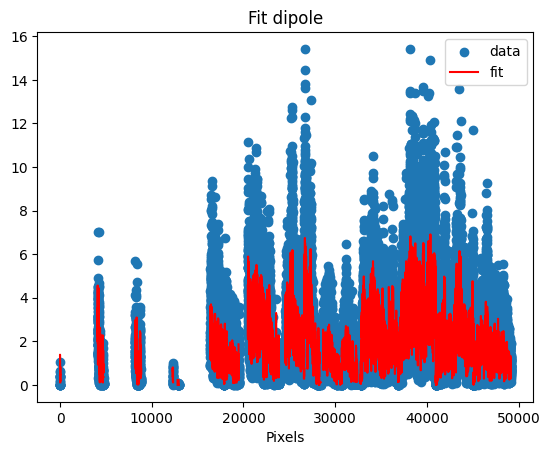

In [25]:
model_1 = observMapper._instance_settingsFit_MD["model"]
observMapper._instance_settingsFit_MD["model"] = lambda hpmap, M, A, ra, dec, contrast : model_1(hpmap, M, A, ra, dec, contrast) * ratioMapper.mapMasked

observMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.944e+04 (χ²/ndof = 0.6)  │              Nfcn = 323              │
│ EDM = 1.8e-05 (Goal: 0.0002)     │            time = 3.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.63e3  │  0.26e3   │  -0.26e3   │   0.26e3   │    0    │         │       │
│ 1 │ A    │ 100.19e-3 │  0.28e-3  │  -0.28e-3  │  0.28e-3   │    0    │    1    │       │
│ 2 │ ra   │  168.00   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │   -6.89   │   0.27    │   -0.27    │    0.27    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.26e3  │  0.26e3   │ -0.28e-3  │  0.28e-3  │   -0.15   │   0.15    │   -0.27   │   0.27    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │     6.63e+04 -30.25814e-3       -0.520        55.29 │
│   A │ -30.25814e-3     7.89e-08      1.34e-6    -25.67e-6 │
│  ra │       -0.520      1.34e-6       0.0232       -0.003 │
│ dec │        55.29    -25.67e-6       -0.003       0.0747 │
└─────┴─────────────────────────────────────────────────────┘

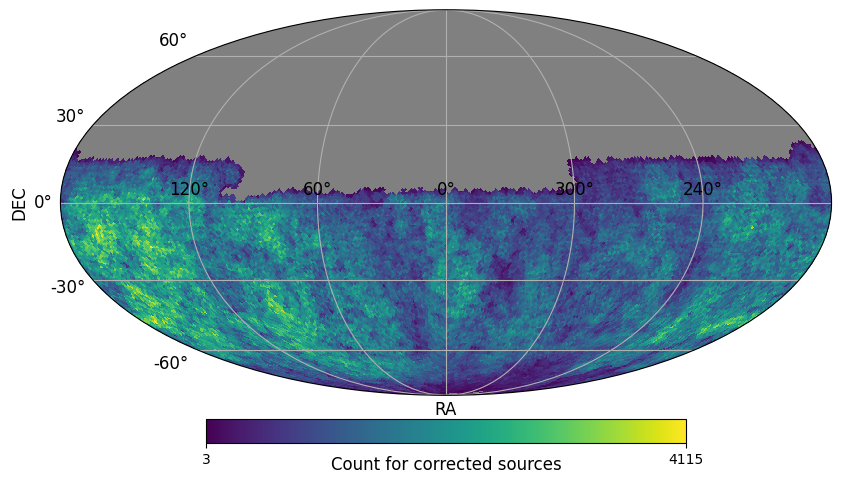

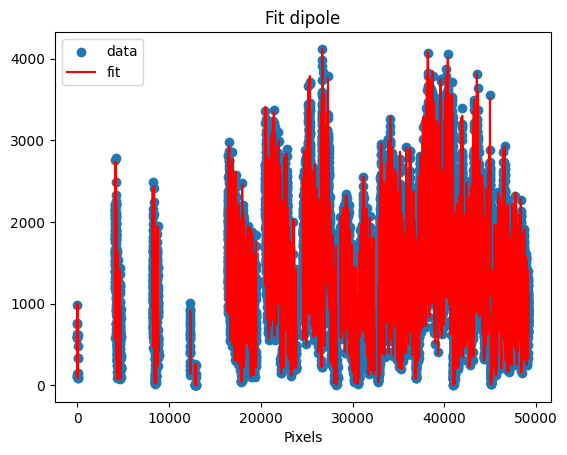

In [27]:
model_1 = correctMapper._instance_settingsFit_MD["model"]
correctMapper._instance_settingsFit_MD["model"] = lambda hpmap, M, A, ra, dec, contrast : model_1(hpmap, M, A, ra, dec, contrast) * ratioMapper.mapMasked

correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.234e+05 (χ²/ndof = 2.5)  │              Nfcn = 329              │
│ EDM = 2.86e-06 (Goal: 0.0002)    │            time = 2.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.28e3  │  0.26e3   │  -0.26e3   │   0.26e3   │    0    │         │       │
│ 1 │ A    │ 101.06e-3 │  0.28e-3  │  -0.28e-3  │  0.28e-3   │    0    │    1    │       │
│ 2 │ ra   │  168.22   │   0.15    │   -0.15    │    0.15    │    0    │   360   │       │
│ 3 │ dec  │   -6.22   │   0.27    │   -0.27    │    0.27    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.26e3  │  0.26e3   │ -0.28e-3  │  0.28e-3  │   -0.15   │   0.15    │   -0.27   │   0.27    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │     6.62e+04 -29.18355e-3       -0.463        54.99 │
│   A │ -29.18355e-3     7.81e-08      1.25e-6    -24.58e-6 │
│  ra │       -0.463      1.25e-6       0.0228       -0.003 │
│ dec │        54.99    -24.58e-6       -0.003       0.0738 │
└─────┴─────────────────────────────────────────────────────┘

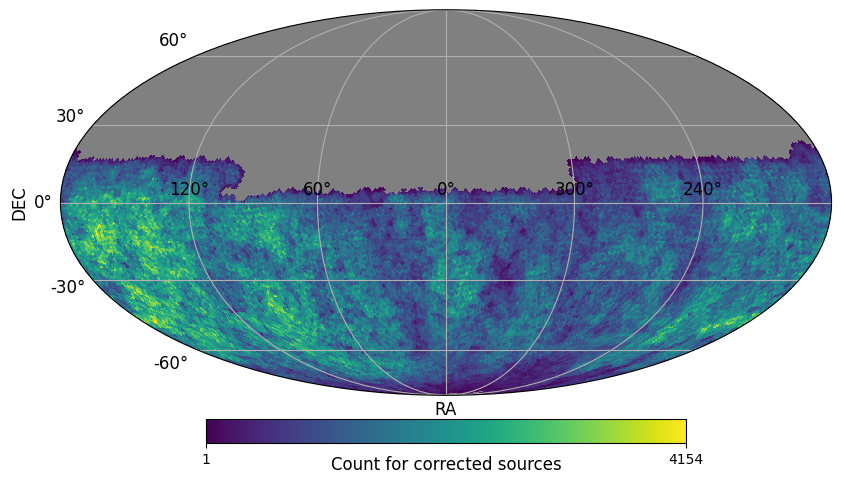

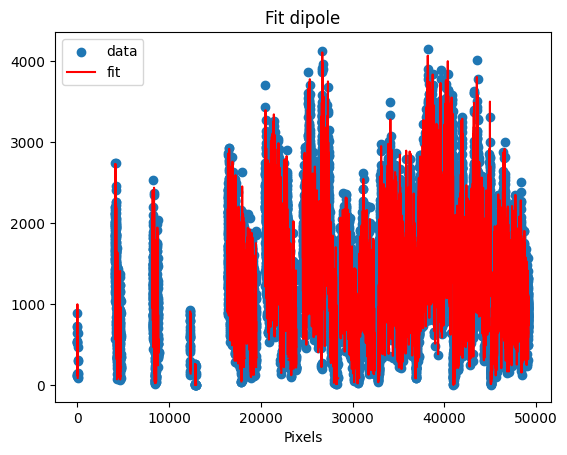

In [29]:
correctMapper = CountMapper.from_map_fits(data3, 49, HDU=f"A_STUDY_MAPS_{band}", IDinunit=False)
correctMapper._set_suffixTextPlot(unit = "corrected sources")
correctMapper.set_mask()


model_1 = correctMapper._instance_settingsFit_MD["model"]
correctMapper._instance_settingsFit_MD["model"] = lambda hpmap, M, A, ra, dec, contrast : model_1(hpmap, M, A, ra, dec, contrast) * ratioMapper.mapMasked

correctMapper.fit_dipole("Masked", init=(NSource_px_th, 1, 100, 0))